In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Phase 1: Feature Engineering and Baseline Modeling
**Capstone Project:** Population & Economic Dynamics in Puerto Rico

As outlined in our predictive framework, this notebook establishes the data foundation and baseline performance metrics. Before deploying complex non-linear models (like Random Forest), we must first clean the data, engineer domain-specific features, and train a straightforward baseline model (Ordinary Least Squares Linear Regression) to serve as our benchmark.

### The Predictive Pipeline


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from math import radians, cos, sin, asin, sqrt

# Scikit-Learn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Helper function for geographic distance
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * 6371 # Radius of earth in km

## 1. Data Ingestion & Preprocessing
We begin by loading our consolidated master dataset, which includes Census population estimates, vital statistics (births/deaths), employer establishments, CDC Social Vulnerability Index (SVI) metrics, and historical hurricane tracks.


In [5]:
# Load the master profile
# Ensure the file is in your 'data/' directory or update the path accordingly
df = pd.read_csv('../data/puerto_rico_master_profile.csv')

# Standardize municipio names (stripping ' Municipio' suffix for cleaner charts)
df['municipio'] = df['municipio'].str.replace(' Municipio', '', case=False).str.strip()

# Sort by municipality and year for time-series operations
df = df.sort_values(by=['municipio', 'year']).reset_index(drop=True)

print(f"Loaded {df.shape[0]} rows across {df['municipio'].nunique()} municipalities.")
df.head()


Loaded 1170 rows across 78 municipalities.


,year,municipio,geoid,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,unemployment_rate_pct,...,disability_pct,single_parent_pct,minority_pct,limited_english_pct,multi_unit_housing_pct,mobile_homes_pct,crowding_pct,no_vehicle_pct,group_quarters_count,pct_group_quarters
0,2010,Adjuntas,72001,19541,0,14834,99,6548,133,20.7,...,0.00,9.50,99.13,14.52,4.15,0.20,7.10,24.56,94,0.00
1,2011,Adjuntas,72001,19514,0,15000,107,6834,161,25.3,...,0.00,10.62,99.17,14.35,3.95,0.18,5.98,23.81,82,0.00
2,2012,Adjuntas,72001,19458,0,15081,80,7037,114,23.1,...,21.88,12.77,99.28,14.10,4.15,0.00,5.73,22.95,72,0.37
3,2013,Adjuntas,72001,19334,0,15087,79,7298,140,27.2,...,22.51,12.30,99.42,14.69,3.55,0.00,4.94,22.16,65,0.34
4,2014,Adjuntas,72001,19188,0,15080,88,7514,136,34.0,...,19.90,12.85,99.82,13.76,3.46,0.00,5.21,20.51,72,0.38


In [ ]:
# 1. Load Master Profile
df = pd.read_csv('../data/puerto_rico_master_profile.csv')
df['municipio'] = df['municipio'].str.replace(' Municipio', '', case=False).str.strip()
df = df.sort_values(by=['municipio', 'year'])

# 2. Add Municipality Centroids for spatial matching
municipio_coords = {
    'Adjuntas': (18.1627, -66.7222), 'Aguada': (18.3605, -67.1882), 'Aguadilla': (18.4275, -67.1541),
    'Aguas Buenas': (18.2572, -66.1031), 'Aibonito': (18.1408, -66.2663), 'Añasco': (18.2827, -67.1399),
    'Arecibo': (18.4724, -66.7157), 'Arroyo': (17.9658, -66.0614), 'Barceloneta': (18.4505, -66.5385),
    'Barranquitas': (18.1861, -66.3061), 'Bayamón': (18.3808, -66.1557), 'Cabo Rojo': (18.0866, -67.1457),
    'Caguas': (18.2325, -66.0391), 'Camuy': (18.4838, -66.8450), 'Canóvanas': (18.3791, -65.9011),
    'Carolina': (18.3808, -65.9574), 'Cataño': (18.4388, -66.1182), 'Cayey': (18.1119, -66.1663),
    'Ceiba': (18.2633, -65.6474), 'Ciales': (18.3361, -66.4688), 'Cidra': (18.1758, -66.1617),
    'Coamo': (18.0855, -66.3579), 'Comerío': (18.2183, -66.2257), 'Corozal': (18.3411, -66.3161),
    'Culebra': (18.3030, -65.3010), 'Dorado': (18.4588, -66.2677), 'Fajardo': (18.3258, -65.6524),
    'Florida': (18.3625, -66.5614), 'Guánica': (17.9716, -66.9080), 'Guayama': (17.9741, -66.1100),
    'Guayanilla': (18.0130, -66.7919), 'Guaynabo': (18.3580, -66.1111), 'Gurabo': (18.2544, -65.9728),
    'Hatillo': (18.4863, -66.8250), 'Hormigueros': (18.1397, -67.1274), 'Humacao': (18.1497, -65.8274),
    'Isabela': (18.5011, -67.0247), 'Jayuya': (18.2186, -66.5916), 'Juana Díaz': (18.0525, -66.5064),
    'Juncos': (18.2275, -65.9211), 'Lajas': (18.0497, -67.0594), 'Lares': (18.2947, -66.8771),
    'Las Marías': (18.2514, -66.9922), 'Las Piedras': (18.1827, -65.8661), 'Loíza': (18.4330, -65.8797),
    'Luquillo': (18.3725, -65.7166), 'Manatí': (18.4274, -66.4922), 'Maricao': (18.1808, -66.9799),
    'Maunabo': (18.0072, -65.8994), 'Mayagüez': (18.2011, -67.1397), 'Moca': (18.3947, -67.1131),
    'Morovis': (18.3258, -66.4053), 'Naguabo': (18.2119, -65.7350), 'Naranjito': (18.3008, -66.2447),
    'Orocovis': (18.2269, -66.4411), 'Patillas': (18.0066, -66.0161), 'Peñuelas': (18.0622, -66.7219),
    'Ponce': (18.0111, -66.6141), 'Quebradillas': (18.4738, -66.9385), 'Rincón': (18.3403, -67.2500),
    'Río Grande': (18.3794, -65.8311), 'Sabana Grande': (18.0777, -66.9605), 'Salinas': (17.9775, -66.2974),
    'San Germán': (18.0816, -67.0400), 'San Juan': (18.4655, -66.1057), 'San Lorenzo': (18.1894, -65.9611),
    'San Sebastián': (18.3372, -66.9905), 'Santa Isabel': (17.9666, -66.4050), 'Toa Alta': (18.3883, -66.2485),
    'Toa Baja': (18.4438, -66.2591), 'Trujillo Alto': (18.3547, -66.0072), 'Utuado': (18.2655, -66.7005),
    'Vega Alta': (18.4119, -66.3314), 'Vega Baja': (18.4438, -66.3874), 'Vieques': (18.1261, -65.4400),
    'Villalba': (18.1275, -66.4925), 'Yabucoa': (18.0505, -65.8794), 'Yauco': (18.0350, -66.8499)
}
df['lat'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[0])
df['lon'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[1])

In [17]:
# 1. Load Natural Disaster Data
hurricane_tracks = pd.read_csv('../data/natural_disasters/caribbean_hurricane_tracks_2010_2025.csv')
with open('../data/natural_disasters/puerto_rico_earthquakes.json') as f:
    eq_data = pd.DataFrame(json.load(f))
eq_data['year'] = pd.to_datetime(eq_data['date']).dt.year

# 2. Define Shock Calculators
def get_max_wind(row):
    year_tracks = hurricane_tracks[hurricane_tracks['Year'] == row['year']]
    if year_tracks.empty or pd.isna(row['lat']): return 0
    year_tracks = year_tracks.copy()
    year_tracks['dist'] = year_tracks.apply(lambda t: haversine(row['lon'], row['lat'], t['Lon'], t['Lat']), axis=1)
    nearby = year_tracks[year_tracks['dist'] <= 100] # 100km radius
    return nearby['Wind_Knots'].max() if not nearby.empty else 0

def get_max_seismic(row):
    year_eq = eq_data[(eq_data['year'] == row['year']) & (eq_data['mag'] >= 4.0)]
    if year_eq.empty or pd.isna(row['lat']): return 0
    year_eq = year_eq.copy()
    year_eq['dist'] = year_eq.apply(lambda e: haversine(row['lon'], row['lat'], e['longitude'], e['latitude']), axis=1)
    nearby = year_eq[year_eq['dist'] <= 50] # 50km radius
    return nearby['mag'].max() if not nearby.empty else 0

# 3. Apply Shock Processing
print("Calculating Hurricane impacts (e.g., Maria, Fiona)...")
df['max_wind_knots'] = df.apply(get_max_wind, axis=1)
print("Calculating Seismic impacts (e.g., 2020 swarm)...")
df['max_seismic_mag'] = df.apply(get_max_seismic, axis=1)

Calculating Hurricane impacts (e.g., Maria, Fiona)...
Calculating Seismic impacts (e.g., 2020 swarm)...


Calculating Hurricane impacts (this may take a minute)...
Calculating Seismic impacts...


KeyboardInterrupt: 

## 2. Feature Engineering & Dimensionality Reduction
Per our methodology, we engineer new features to better capture demographic momentum and economic shocks.

1. **Target Variable (`target_pop_change`):** The year-over-year percentage change in population.
2. **Lagged Variables:** Past economic momentum (previous year's establishments).
3. **Natural Change Rate:** Birth Rate minus Death Rate.
4. **Dimensionality Reduction (PCA):** The CDC SVI variables are highly collinear. We use PCA to compress them into a single "SVI_Composite_Score" to reduce noise.


In [19]:
# 1. Calculate target (Annual % Pop Change)
df['target_pop_change'] = df.groupby('municipio')['total_population'].pct_change() * 100
df_clean = df.dropna(subset=['target_pop_change']).copy()

# 2. PCA on SVI Columns
svi_cols = ['poverty_rate_pct', 'unemployment_rate_pct', 'no_hs_diploma_pct', 'disability_pct', 'no_vehicle_pct']
scaler = StandardScaler()
svi_scaled = scaler.fit_transform(df_clean[svi_cols])
pca = PCA(n_components=1)
df_clean['vulnerability_index'] = pca.fit_transform(svi_scaled)

# 3. Define the final features for the model including SHOCKS
features = ['vulnerability_index', 'median_income_real', 'over_65_pct', 'max_wind_knots', 'max_seismic_mag']
X = df_clean[features]
y = df_clean['target_pop_change']

print(f"Features ready for baseline model: {features}")

Features ready for baseline model: ['vulnerability_index', 'median_income_real', 'over_65_pct', 'max_wind_knots', 'max_seismic_mag']


## 3. Baseline Model: Ordinary Least Squares (OLS)
We split our data into an 80/20 Training and Test set. We apply standard scaling to our features so that our regression coefficients are directly comparable. 

We use a simple Linear Regression model as our benchmark. This requires minimal tuning and establishes a performance "floor" that our future Random Forest model must exceed.


In [21]:
# 1. Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale the features (Crucial for regularized regression and comparing coefficients)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# 3. Initialize and Train the Baseline Linear Regression Model
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

# Generate Predictions
y_pred_train = baseline_model.predict(X_train_scaled)
y_pred_test = baseline_model.predict(X_test_scaled)

print("Baseline Model Trained Successfully.")


Baseline Model Trained Successfully.


## 4. Evaluation & Next Steps
We evaluate our baseline model using **R-squared ($R^2$)** and **Root Mean Squared Error (RMSE)**. We also examine the feature coefficients to see which variables had the strongest linear relationship with population decline.


--- BASELINE MODEL PERFORMANCE ---
Test R-squared: 0.0144
Test RMSE:      2.1114 %
--------------------------------


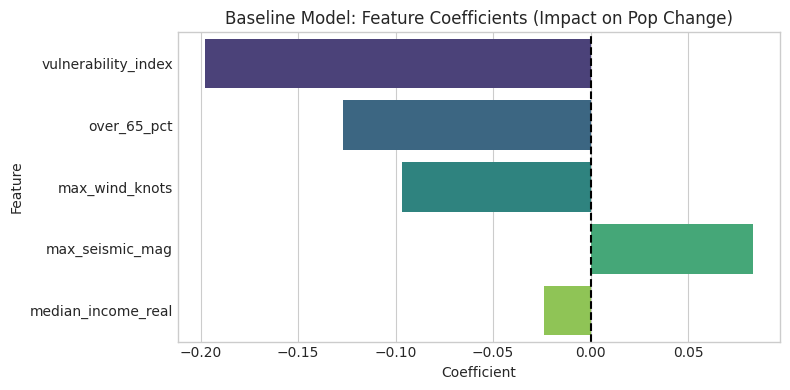

In [22]:
# Calculate Metrics
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("--- BASELINE MODEL PERFORMANCE ---")
print(f"Test R-squared: {r2_test:.4f}")
print(f"Test RMSE:      {rmse_test:.4f} %")
print("-" * 32)

# Plot Feature Coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': baseline_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Baseline Model: Feature Coefficients (Impact on Pop Change)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()
